# Comparação entre os grupos — Control vs Test

Controle: **Maximum Bidding** · Teste: **Average Bidding**.

Duas correções em relação à versão anterior deste notebook:

1. **ROI foi removido.** O dataset não tem receita — só contagens e gasto —
   então ROI (`(receita - gasto) / gasto`) é **incalculável** aqui. No lugar,
   as métricas deriváveis de verdade: CPA, CTR, CPC, CPM, taxa de carrinho
   e taxa de compra.
2. **A conclusão é calculada, não digitada.** A versão anterior fixava os
   percentuais (`+18.8`, `-1.9`, `-12.9`) como constantes no código e depois
   imprimia uma recomendação a partir deles.

Além disso, o teste de significância decide se a diferença é ruído ou real.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.width", 220)

plt.style.use("dark_background")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 12

warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Carga

In [2]:
SEP = ";"


def carregar(caminho, rotulo):
    df = pd.read_csv(caminho, sep=SEP)
    df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y", dayfirst=True)
    return df.sort_values("Date").reset_index(drop=True), rotulo


df_CG_fixed, rotulo_CG = carregar("../data/control_group.csv", "Controle")
df_TG_fixed, rotulo_TG = carregar("../data/test_group.csv", "Teste")

print(f"{rotulo_CG}: {len(df_CG_fixed)} dias | {rotulo_TG}: {len(df_TG_fixed)} dias")
df_CG_fixed.head()

Controle: 30 dias | Teste: 30 dias


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Métricas derivadas

O dataset traz gasto e contagens de funil, mas não traz receita. Por isso o ROI não é calculável — as métricas abaixo são as que os dados sustentam de fato.

In [3]:
TOTAIS = {
    "cliques": "# of Website Clicks",
    "impressoes": "# of Impressions",
    "carrinhos": "# of Add to Cart",
    "compras": "# of Purchase",
}


def derivar(df):
    """Métricas de custo e de funil. CPA = gasto / compras."""
    out = df.copy()
    out["CPA"] = out["Spend [USD]"] / out[TOTAIS["compras"]].replace(0, np.nan)
    out["CTR"] = out[TOTAIS["cliques"]] / out[TOTAIS["impressoes"]].replace(0, np.nan)
    out["CPC"] = out["Spend [USD]"] / out[TOTAIS["cliques"]].replace(0, np.nan)
    out["CPM"] = out["Spend [USD]"] / out[TOTAIS["impressoes"]].replace(0, np.nan) * 1000
    out["Taxa carrinho"] = out[TOTAIS["carrinhos"]] / out[TOTAIS["cliques"]].replace(0, np.nan)
    out["Taxa compra"] = out[TOTAIS["compras"]] / out[TOTAIS["cliques"]].replace(0, np.nan)
    return out


CG = derivar(df_CG_fixed)
TG = derivar(df_TG_fixed)

resumo = pd.DataFrame(
    {
        "Controle": CG.mean(numeric_only=True),
        "Teste": TG.mean(numeric_only=True),
    }
)
resumo["Δ %"] = (resumo["Teste"] - resumo["Controle"]) / resumo["Controle"] * 100
resumo.round(3)

,Controle,Teste,Δ %
Spend [USD],2288.433,2563.067,12.001
# of Impressions,109559.759,73215.483,-33.173
Reach,88844.931,52055.483,-41.409
# of Website Clicks,5320.793,6038.172,13.483
# of Searches,2221.310,2429.759,9.384
# of View Content,1943.793,1892.483,-2.640
# of Add to Cart,1300.000,878.966,-32.387
# of Purchase,522.793,512.724,-1.926
CPA,5.052,6.000,18.755
CTR,0.051,0.104,104.451


## 3. Gasto e volume absolutos

In [4]:
totais = pd.DataFrame(
    {
        "Gasto (USD)": [CG["Spend [USD]"].sum(), TG["Spend [USD]"].sum()],
        "Impressões": [CG["# of Impressions"].sum(), TG["# of Impressions"].sum()],
        "Cliques": [CG["# of Website Clicks"].sum(), TG["# of Website Clicks"].sum()],
        "Compras": [CG["# of Purchase"].sum(), TG["# of Purchase"].sum()],
    },
    index=["Controle", "Teste"],
)
totais["Δ %"] = (totais.loc["Teste"] - totais.loc["Controle"]) / totais.loc["Controle"] * 100
totais.round(2)

,Gasto (USD),Impressões,Cliques,Compras,Δ %
Controle,68653,3177233.0,154303.0,15161.0,NaN
Teste,76892,2123249.0,175107.0,14869.0,NaN


### 3.1. Comparação das contagens bruteiras (média diária)

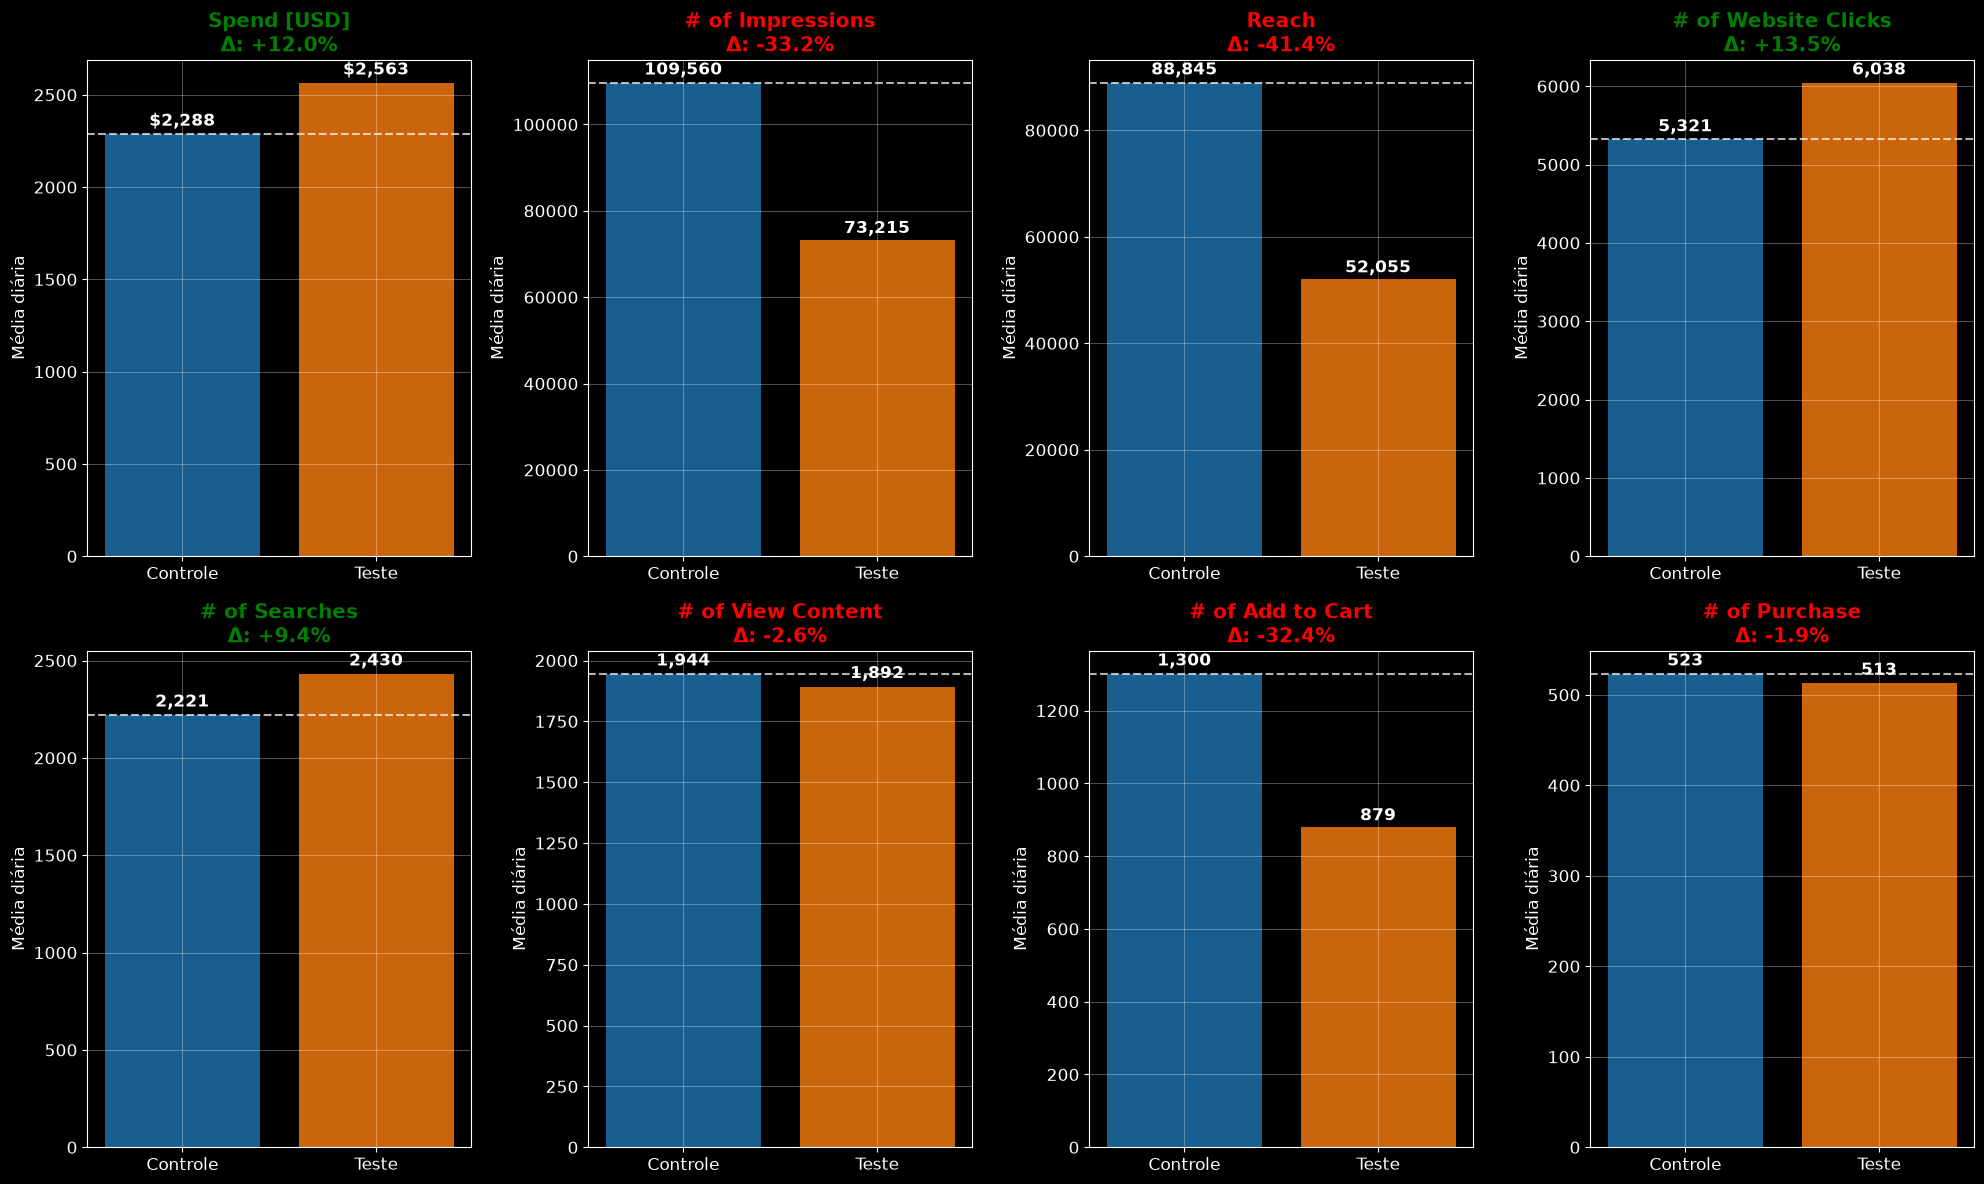

In [5]:
metrics = [
    "Spend [USD]",
    "# of Impressions",
    "Reach",
    "# of Website Clicks",
    "# of Searches",
    "# of View Content",
    "# of Add to Cart",
    "# of Purchase",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    media_control = CG[metric].mean()
    media_test = TG[metric].mean()

    bars = axes[i].bar(["Controle", "Teste"], [media_control, media_test],
                       color=["#1f77b4", "#ff7f0e"], alpha=0.8)
    axes[i].axhline(y=media_control, color="white", linestyle="--", alpha=0.7)

    for bar, value in zip(bars, [media_control, media_test]):
        altura = bar.get_height()
        rotulo = f"${value:,.0f}" if metric == "Spend [USD]" else f"{value:,.0f}"
        axes[i].text(bar.get_x() + bar.get_width() / 2, altura * 1.01,
                     rotulo, ha="center", va="bottom", fontweight="bold")

    pct = (media_test - media_control) / media_control * 100 if media_control else 0
    axes[i].set_title(f"{metric}\nΔ: {pct:+.1f}%",
                      color="green" if pct > 0 else "red", fontweight="bold")
    axes[i].set_ylabel("Média diária")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2. Investimento total

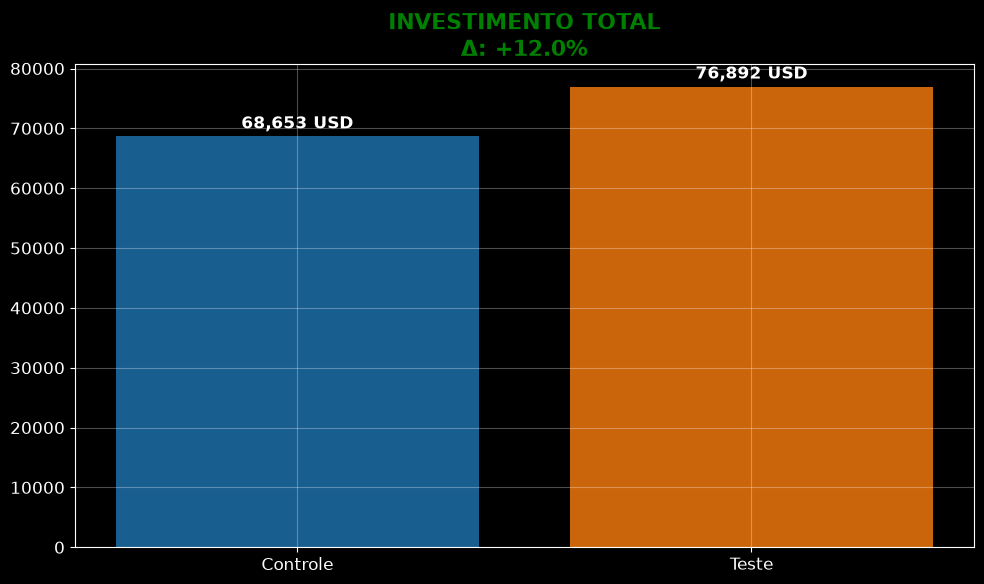

In [6]:
def barras_totais(titulo, valores, sufixo=""):
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(["Controle", "Teste"], valores, color=["#1f77b4", "#ff7f0e"], alpha=0.8)
    for bar, value in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{value:,.0f}{sufixo}", ha="center", va="bottom", fontweight="bold")
    delta = (valores[1] - valores[0]) / valores[0] * 100
    ax.set_title(f"{titulo}\nΔ: {delta:+.1f}%",
                 color="green" if delta > 0 else "red", fontweight="bold", fontsize=16)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


barras_totais("INVESTIMENTO TOTAL", [CG["Spend [USD]"].sum(), TG["Spend [USD]"].sum()], " USD")

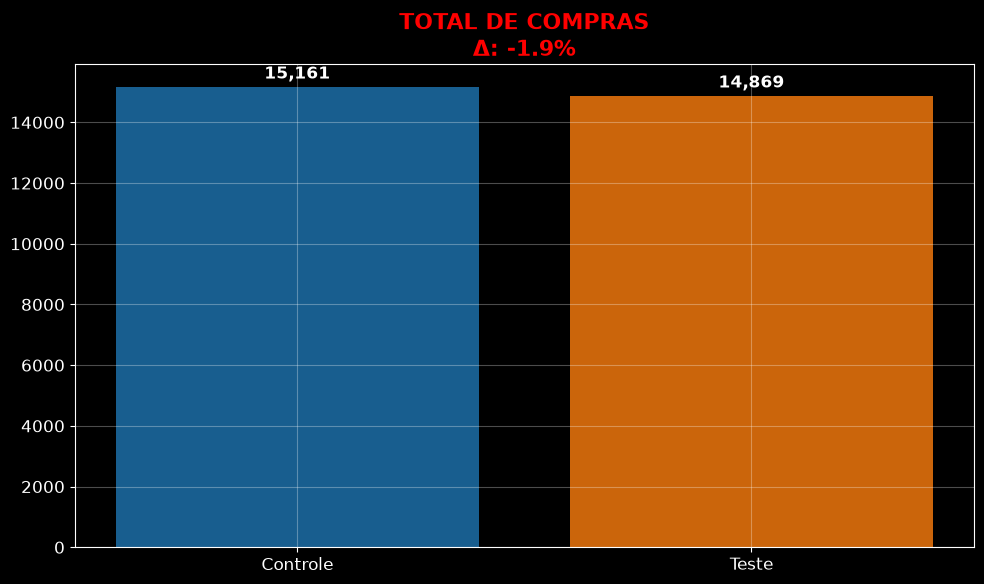

In [7]:
barras_totais("TOTAL DE COMPRAS", [CG["# of Purchase"].sum(), TG["# of Purchase"].sum()])

### 3.3. CPA — custo por compra (o que substituiu o ROI inexistente)

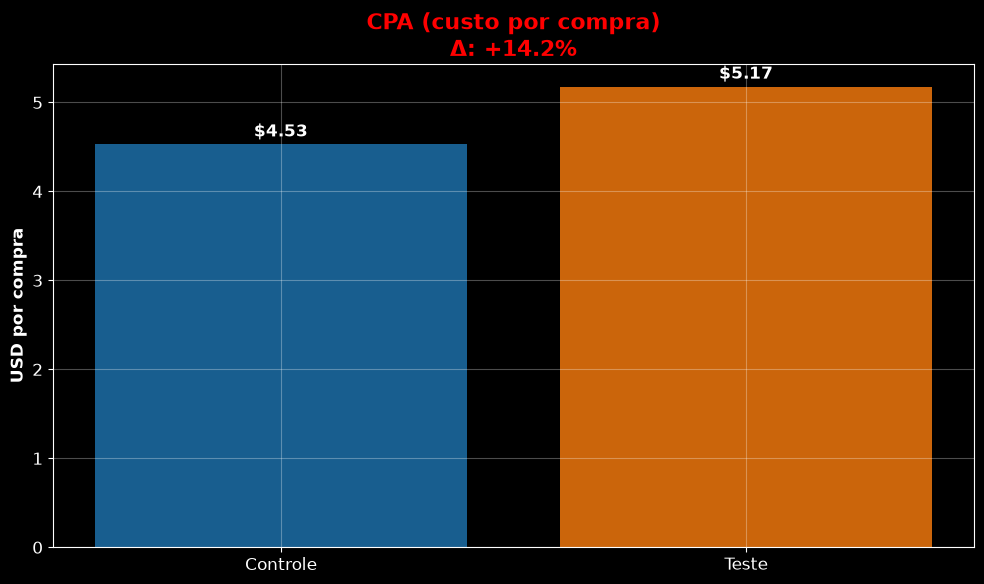

CPA Controle: $4.53
CPA Teste:    $5.17


In [8]:
cpa_control = CG["Spend [USD]"].sum() / CG["# of Purchase"].sum()
cpa_test = TG["Spend [USD]"].sum() / TG["# of Purchase"].sum()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(["Controle", "Teste"], [cpa_control, cpa_test],
              color=["#1f77b4", "#ff7f0e"], alpha=0.8)
for bar, value in zip(bars, [cpa_control, cpa_test]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"${value:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=12)

delta_cpa = (cpa_test - cpa_control) / cpa_control * 100
# CPA menor e melhor, entao o sinal da cor e invertido em relacao as demais metricas
ax.set_title(f"CPA (custo por compra)\nΔ: {delta_cpa:+.1f}%",
             color="red" if delta_cpa > 0 else "green", fontweight="bold", fontsize=16)
ax.set_ylabel("USD por compra", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"CPA Controle: ${cpa_control:.2f}")
print(f"CPA Teste:    ${cpa_test:.2f}")

### 3.4. Taxas de funil

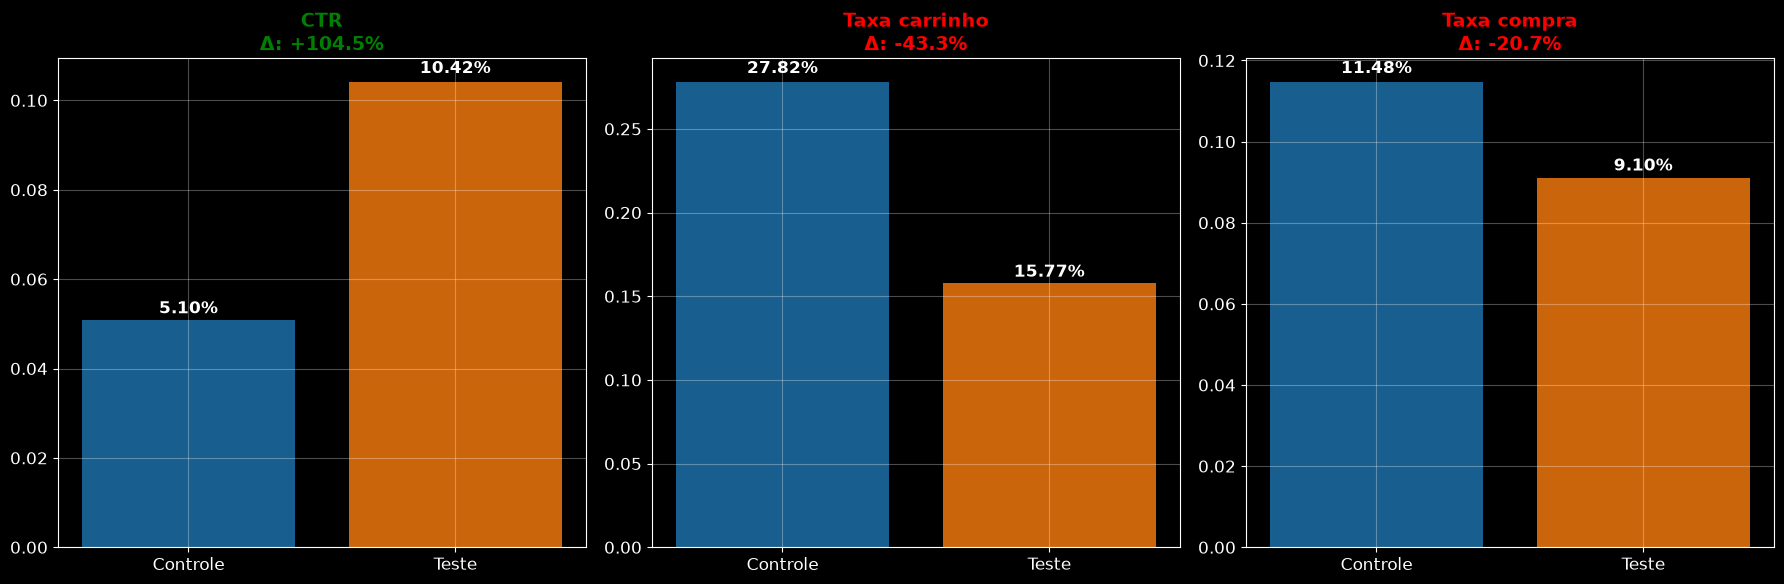

In [9]:
taxas = ["CTR", "Taxa carrinho", "Taxa compra"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, taxa in zip(axes, taxas):
    valores = [CG[taxa].mean(), TG[taxa].mean()]
    bars = ax.bar(["Controle", "Teste"], valores, color=["#1f77b4", "#ff7f0e"], alpha=0.8)
    for bar, value in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{value:.2%}", ha="center", va="bottom", fontweight="bold")
    delta = (valores[1] - valores[0]) / valores[0] * 100
    ax.set_title(f"{taxa}\nΔ: {delta:+.1f}%",
                 color="green" if delta > 0 else "red", fontweight="bold", fontsize=14)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. A diferença é real ou é ruído?

Aqui está a pegadinha clássica deste dataset, e ela muda a conclusão.

O número óbvio é o z-test sobre as contagens agregadas: 175 mil cliques no
teste contra 154 mil no controle. Mas **cliques dentro do mesmo dia não são
independentes** — o dia traz a mesma condição de tempo, a mesma verba e a mesma
público-alvo. Somar 175 mil cliques como se fossem 175 mil observações
independentes é *pseudoreplicação*: infla o n e zera o p-value.

A unidade experimental real é o **dia**, então são 30 observações por braço.
O teste principal é o **t-test de Welch** sobre a taxa de compra diária, com o
Mann-Whitney como checagem não-paramétrica. O z-test aparece só para mostrar
por que ele engana.

In [10]:
ALFA = 0.05

compras_c, cliques_c = CG["# of Purchase"].sum(), CG["# of Website Clicks"].sum()
compras_t, cliques_t = TG["# of Purchase"].sum(), TG["# of Website Clicks"].sum()

# --- taxa diaria: a unidade experimental correta (1 ponto por dia) ---
diaria_cg = CG["Taxa compra"].dropna()
diaria_tg = TG["Taxa compra"].dropna()


def z_test_ingenuo(sucesso_a, total_a, sucesso_b, total_b):
    """z-test de duas proporcoes. ASSUME independência entre cliques — violada aqui."""
    p1, p2 = sucesso_a / total_a, sucesso_b / total_b
    p_pool = (sucesso_a + sucesso_b) / (total_a + total_b)
    erro = np.sqrt(p_pool * (1 - p_pool) * (1 / total_a + 1 / total_b))
    z = (p2 - p1) / erro
    return p1, p2, z, 2 * (1 - stats.norm.cdf(abs(z)))


p_cg, p_tg, z_ingenuo, p_z_ingenuo = z_test_ingenuo(
    compras_c, cliques_c, compras_t, cliques_t
)
t_stat, p_t = stats.ttest_ind(diaria_tg, diaria_cg, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(diaria_tg, diaria_cg, alternative="two-sided")

print("=== TESTE PRINCIPAL: taxa de compra DIARIA (n = 30 por braco) ===")
print(f"  Controle: {diaria_cg.mean():.4%} (desvio {diaria_cg.std():.4%})")
print(f"  Teste:    {diaria_tg.mean():.4%} (desvio {diaria_tg.std():.4%})")
print(f"  t-test de Welch  : t = {t_stat:.3f} | p = {p_t:.4f} -> "
      f"{'REJEITA H0' if p_t < ALFA else 'NAO REJEITA H0'}")
print(f"  Mann-Whitney U   : U = {u_stat:.1f} | p = {p_u:.4f} -> "
      f"{'REJEITA H0' if p_u < ALFA else 'NAO REJEITA H0'}")
print()
print("=== TESTE INGENUO: proporcoes sobre as contagens agregadas ===")
print(f"  Controle: {p_cg:.4%} ({compras_c:,.0f} / {cliques_c:,.0f})")
print(f"  Teste:    {p_tg:.4%} ({compras_t:,.0f} / {cliques_t:,.0f})")
print(f"  z = {z_ingenuo:.3f} | p = {p_z_ingenuo:.2e}")
print("  ^ Parece significativo, mas so porque trata 175 mil cliques como independentes.")
print("    Cliques do mesmo dia sao correlacionados; esse p-value nao e confiavel.")

significante = p_t < ALFA
print()
print("VEREDITO DE SIGNIFICANCIA (usa o teste diario):",
      "diferenca significativa." if significante
      else f"diferenca NAO significativa (p = {p_t:.3f} >= {ALFA}).")

=== TESTE PRINCIPAL: taxa de compra DIARIA (n = 30 por braco) ===
  Controle: 11.4772% (desvio 6.8383%)
  Teste:    9.0978% (desvio 4.4663%)
  t-test de Welch  : t = -1.569 | p = 0.1232 -> NAO REJEITA H0
  Mann-Whitney U   : U = 348.0 | p = 0.2628 -> NAO REJEITA H0

=== TESTE INGENUO: proporcoes sobre as contagens agregadas ===
  Controle: 9.8255% (15,161 / 154,303)
  Teste:    8.4914% (14,869 / 175,107)
  z = -13.274 | p = 0.00e+00
  ^ Parece significativo, mas so porque trata 175 mil cliques como independentes.
    Cliques do mesmo dia sao correlacionados; esse p-value nao e confiavel.

VEREDITO DE SIGNIFICANCIA (usa o teste diario): diferenca NAO significativa (p = 0.123 >= 0.05).


## 5. Conclusão (calculada a partir dos números acima)

A regra de decisão lê o teste diário, não o z-test ingênuo.

In [11]:
print("=" * 68)
print("CONCLUSAO - ANALISE FINANCEIRA DO TESTE A/B")
print("=" * 68)

dados = {
    "Gasto total": (CG["Spend [USD]"].sum(), TG["Spend [USD]"].sum()),
    "Compras": (CG["# of Purchase"].sum(), TG["# of Purchase"].sum()),
    "CPA (USD)": (cpa_control, cpa_test),
}
for nome, (c, t_) in dados.items():
    delta = (t_ - c) / c * 100
    print(f"  {nome:<14} Controle {c:>12,.2f} | Teste {t_:>12,.2f} | delta {delta:+6.1f}%")

print()
print(f"  Taxa de compra diaria: Controle {diaria_cg.mean():.4%} -> Teste {diaria_tg.mean():.4%}")
print(f"  t-test de Welch  p = {p_t:.4f}  ->  "
      f"{'significativo' if significante else 'NAO significativo'} a {ALFA:.0%}")
print(f"  Mann-Whitney U   p = {p_u:.4f}")
print(f"  (z-test ingenuo daria p = {p_z_ingenuo:.2e}, mas ele e pseudoreplicacao)")

# --- regra de decisao, escrita sobre os numeros calculados acima ---
teste_melhor = cpa_test < cpa_control
print()
print("=" * 68)
if significante and teste_melhor:
    print("VEREDITO: adotar o TESTE.")
    print("  CPA menor com conversao significativamente melhor.")
elif significante and not teste_melhor:
    print("VEREDITO: manter a campanha de CONTROLE.")
    print("  Conversao significativamente pior e CPA maior.")
elif not significante and teste_melhor:
    print("VEREDITO: inconclusivo, sem base para trocar.")
    print("  O teste tem CPA menor, mas com 30 dias por braco a diferenca de conversao")
    print(f"  nao atinge significancia (p = {p_t:.3f}). Rodar mais dias antes de decidir.")
else:
    print("VEREDITO: manter a campanha de CONTROLE, por ora.")
    print("  O teste tem CPA pior e a diferenca nao e estatisticamente significativa")
    print(f"  (p = {p_t:.3f}): nao ha ganho que justifique trocar. E, como o teste gasta mais,")
    print("  o custo de esperar por mais dados e menor que o custo de adota-lo errado.")

print()
print("Impacto do periodo, se o teste fosse adotado:")
custo_extra = cpa_test - cpa_control
print(f"  Custo extra por compra:  ${custo_extra:,.2f}")
print(f"  Custo extra em {len(TG)} dias:  ${custo_extra * TG['# of Purchase'].sum():,.2f}")
print("=" * 68)

CONCLUSAO - ANALISE FINANCEIRA DO TESTE A/B
  Gasto total    Controle    68,653.00 | Teste    76,892.00 | delta  +12.0%
  Compras        Controle    15,161.00 | Teste    14,869.00 | delta   -1.9%
  CPA (USD)      Controle         4.53 | Teste         5.17 | delta  +14.2%

  Taxa de compra diaria: Controle 11.4772% -> Teste 9.0978%
  t-test de Welch  p = 0.1232  ->  NAO significativo a 5%
  Mann-Whitney U   p = 0.2628
  (z-test ingenuo daria p = 0.00e+00, mas ele e pseudoreplicacao)

VEREDITO: manter a campanha de CONTROLE, por ora.
  O teste tem CPA pior e a diferenca nao e estatisticamente significativa
  (p = 0.123): nao ha ganho que justifique trocar. E, como o teste gasta mais,
  o custo de esperar por mais dados e menor que o custo de adota-lo errado.

Impacto do periodo, se o teste fosse adotado:
  Custo extra por compra:  $0.64
  Custo extra em 30 dias:  $9,561.25
